In [2]:
!pip install yfinance


[notice] A new release of pip is available: 24.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import yfinance as yf 
import matplotlib.pyplot as plt 
import warnings 
warnings.filterwarnings('ignore')

stock_data = yf.download('AAPL', start='2026-01-01')

[*********************100%***********************]  1 of 1 completed


In [4]:
stock_data.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2026-01-02,270.756653,277.580254,268.748522,272.005484,37838100
2026-01-05,267.010162,271.256189,265.891214,270.387007,45647200
2026-01-06,262.114716,267.299866,261.874950,266.750392,52352100
2026-01-07,260.086609,263.433483,259.567106,262.953951,48309800
2026-01-08,258.797852,259.047618,255.460962,256.779720,50419300


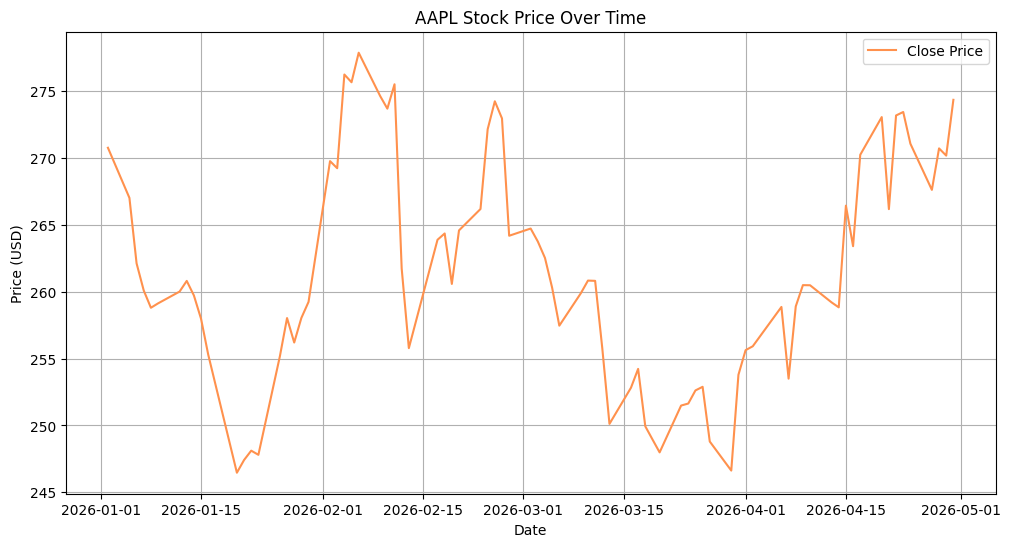

In [5]:
plt.figure(figsize=(12,6))
plt.plot(stock_data.index, stock_data['Close'], label='Close Price', color='#FF914D')
plt.title('AAPL Stock Price Over Time')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

## Classical Time Series Decompostion

In [6]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition_additive = seasonal_decompose(stock_data['Close'], model='additive', period=30)

In [7]:
trend_additive = decomposition_additive.trend
seasonal_additive = decomposition_additive.seasonal
residual_additive = decomposition_additive.resid

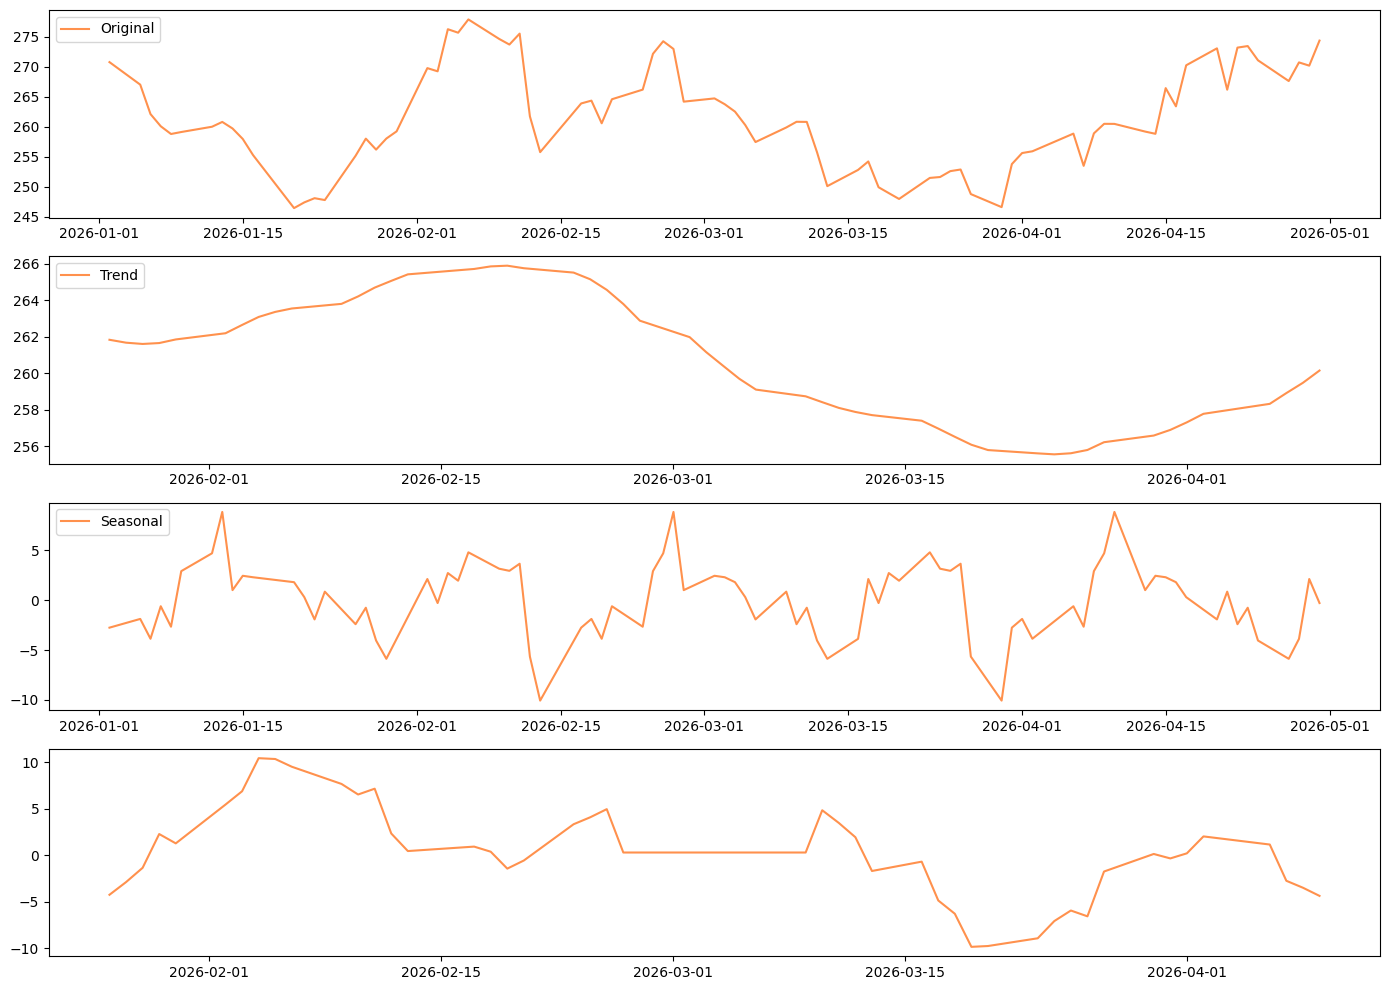

In [8]:
plt.figure(figsize=(14, 10))
plt.subplot(411)
plt.plot(stock_data['Close'], label='Original', color='#FF914D')
plt.legend(loc='upper left')
plt.subplot(412)
plt.plot(trend_additive, label='Trend', color='#FF914D')
plt.legend(loc='upper left')
plt.subplot(413)
plt.plot(seasonal_additive, label='Seasonal', color='#FF914D')
plt.legend(loc='upper left')
plt.subplot(414)
plt.plot(residual_additive, label='Residual', color='#FF914D')
plt.tight_layout()
plt.show()


## STL Decomposing

In [9]:
from statsmodels.tsa.seasonal import STL

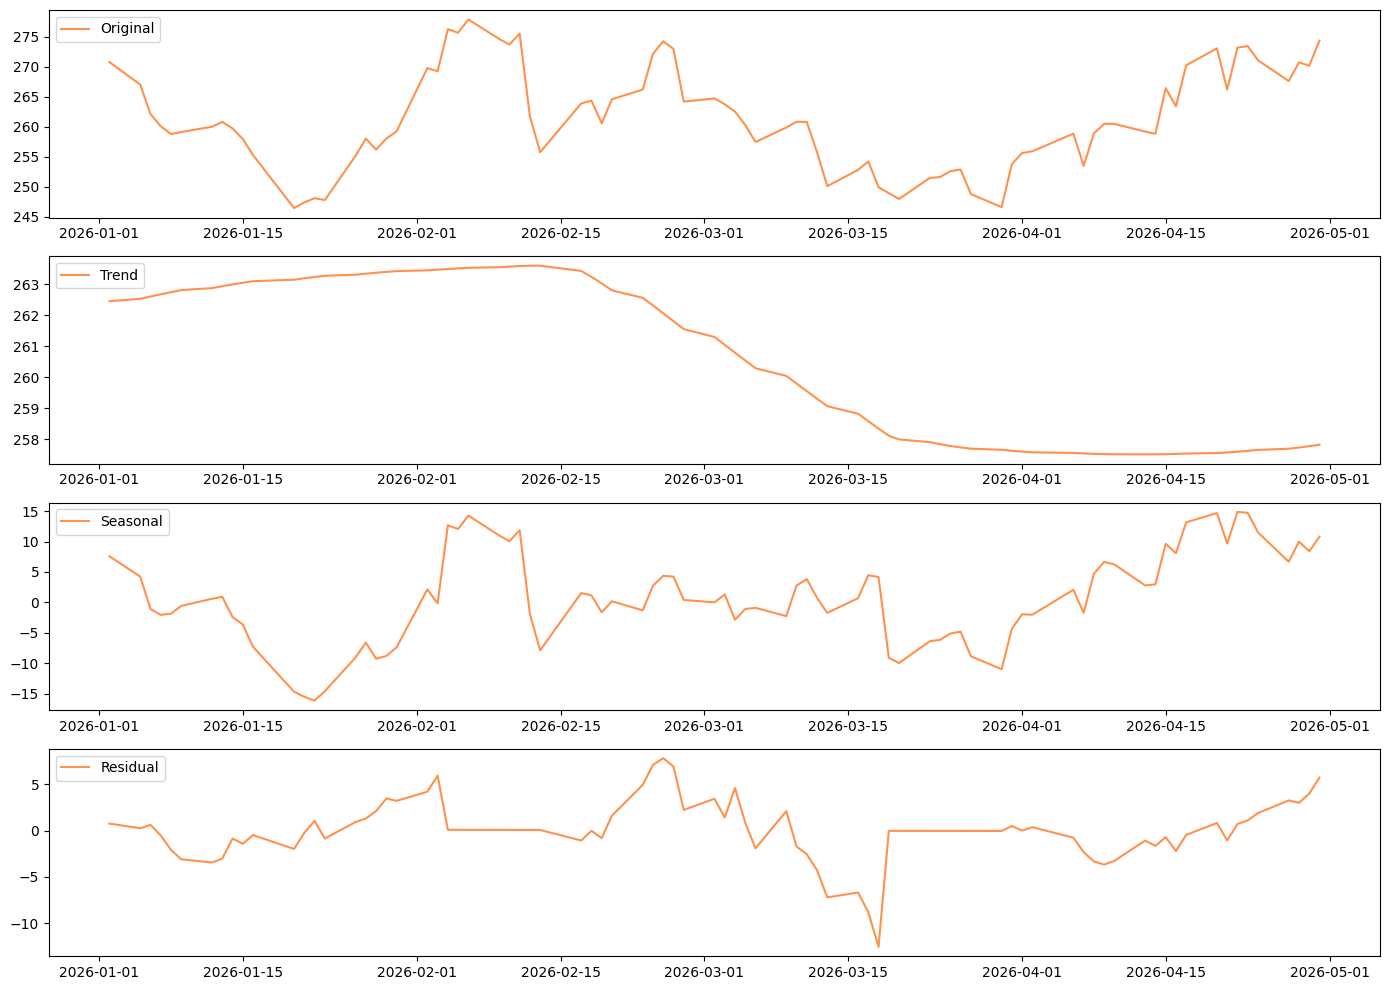

In [10]:
stl = STL(stock_data['Close'], period=30)
result = stl.fit()

plt.figure(figsize=(14, 10))
plt.subplot(411)
plt.plot(result.observed, label='Original', color='#FF914D')
plt.legend(loc='upper left')
plt.subplot(412)
plt.plot(result.trend, label='Trend', color='#FF914D')
plt.legend(loc='upper left')
plt.subplot(413)
plt.plot(result.seasonal, label='Seasonal', color='#FF914D')
plt.legend(loc='upper left')
plt.subplot(414)
plt.plot(result.resid, label='Residual', color='#FF914D')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

## Stationarity Test

In [11]:
from statsmodels.tsa.stattools import adfuller

# Perform the Augmented Dickey-fuller test
ad_test = adfuller(stock_data['Close'])

print('ADF Test Results: ')
print(f'ADF Statistic: {round(ad_test[0], 3)}')
print(f'p-value: {round(ad_test[1], 3)}')
print('Critical Values: ')
for key, value in ad_test[4].items():
    print(f'    {key}: {round(value,3)}')

ADF Test Results: 
ADF Statistic: -2.144
p-value: 0.227
Critical Values: 
    1%: -3.514
    5%: -2.898
    10%: -2.586


In [12]:
from statsmodels.tsa.stattools import kpss

# Perform the KPSS test
kpss_test = kpss(stock_data['Close'], regression='ct')  # 'c' for constant (level stationarity), 'ct' for trend

print('KPSS Test Results: ')
print(f'KPSS Statistic: {round(kpss_test[0], 2)}')
print(f'p-value: {kpss_test[1]}')
print('Critical Values:')
for key, value in kpss_test[3].items():
    print(f'    {key}: {value}')

KPSS Test Results: 
KPSS Statistic: 0.13
p-value: 0.0832607268403818
Critical Values:
    10%: 0.119
    5%: 0.146
    2.5%: 0.176
    1%: 0.216


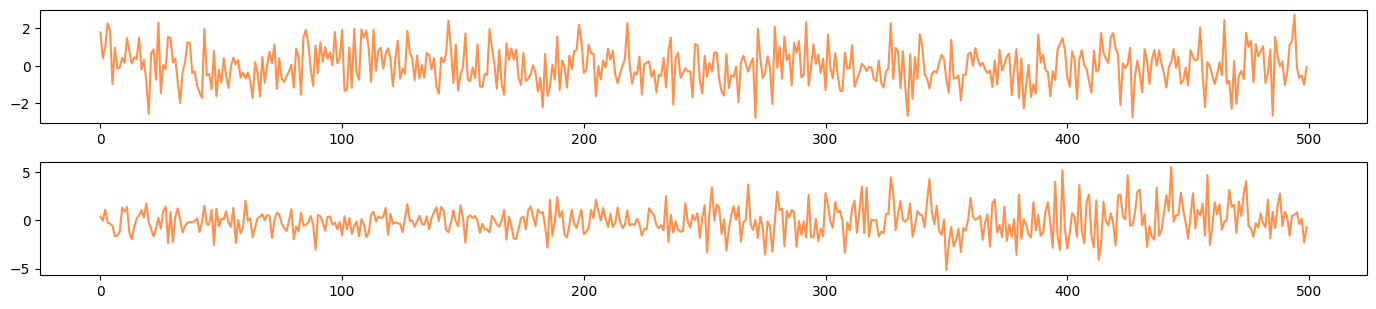

Strict Stationary Series - K-S Test Statistic: 0.068, p-value: 0.6109
Weak Stationary Series - K-S Test Statistic: 0.184, p-value: 0.0004


In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp

# Generating synthectic data for demonstration
np.random.seed(0)
n = 500

# Strictly staionary series: normally distributed random noise
strict_stationary_series = np.random.normal(0, 1, n)

# Non-strictly stationary series: changing variance
non_strict_stationary_series = np.concatenate([
    np.random.normal(0, 1, n // 2),
    np.random.normal(0, 2, n // 2)
])

# Function to split the series into two halves and perform the K-S test
def ks_test_stationarity(series):
    split = len(series) // 2
    series_first_half = series[:split]
    series_second_half = series[split:]
    stat, p_value = ks_2samp(series_first_half, series_second_half)
    return stat, p_value

# Perform the K-S test on strictly stationary series
ks_stat_strict, ks_pvalue_strict = ks_test_stationarity(strict_stationary_series)

# Perform the K-S test on non-strictly stationary series
ks_stat_non_strict, ks_pvalue_non_strict = ks_test_stationarity(non_strict_stationary_series)

# Plotting the series
plt.figure(figsize=(14, 6))
plt.subplot(411)
plt.plot(strict_stationary_series, label='Strict Stationary Series', color='#FF914D')
plt.subplot(412)
plt.plot(non_strict_stationary_series, label='Weak Stationary Series', color='#FF914D')
plt.tight_layout()
plt.show()

print(f'Strict Stationary Series - K-S Test Statistic: {ks_stat_strict}, p-value: {ks_pvalue_strict:.4f}')

print(f'Weak Stationary Series - K-S Test Statistic: {ks_stat_non_strict}, p-value: {ks_pvalue_non_strict:.4f}')

## Making Data Stationary

In [14]:
def adf_test(series):
    result = adfuller(series)
    print('ADF Statistics: ', result[0])
    print('p-value: ', result[1])
    for key, value in result[4].items():
        print('Critical Value (%s): %.3f' % (key, value))

def kpss_test(series):
    result = kpss(series, regression='c')
    print('KPSS Statistic: ', result[0])
    print('p-value: ', result[1])
    for key, value in result[4].items():
        print('Critical Value (%s): %.3f' % (key, value))

In [15]:
prices = stock_data['Close']

In [16]:
adf_test(prices)

ADF Statistics:  -2.1443290762258282
p-value:  0.22706708185196212
Critical Value (1%): -3.514
Critical Value (5%): -2.898
Critical Value (10%): -2.586


In [17]:
prices_diff = prices.diff()
adf_test(prices_diff.dropna())

ADF Statistics:  -8.986385580924198
p-value:  7.0824043487248025e-15
Critical Value (1%): -3.515
Critical Value (5%): -2.898
Critical Value (10%): -2.586


In [18]:
prices

Ticker,AAPL
Date,
2026-01-02,270.756653
2026-01-05,267.010162
2026-01-06,262.114716
2026-01-07,260.086609
2026-01-08,258.797852
...,...
2026-04-24,271.059998
2026-04-27,267.609985
2026-04-28,270.709991


In [19]:
import numpy as np
from scipy import stats

# Log transformation
prices_log = np.log(prices)

# Square root transformation
prices_sqrt = np.sqrt(prices)

prices_1d = prices['AAPL']
# Box-Cox transformation
# Note: Box-Cox requires all positive values
prices_boxcox, lam = stats.boxcox(prices_1d[prices_1d > 0])

In [20]:
adf_test(prices_log)

ADF Statistics:  -2.144526005043877
p-value:  0.2269912725189513
Critical Value (1%): -3.514
Critical Value (5%): -2.898
Critical Value (10%): -2.586


In [21]:
adf_test(prices_sqrt)

ADF Statistics:  -2.1442144415563353
p-value:  0.2271112183748632
Critical Value (1%): -3.514
Critical Value (5%): -2.898
Critical Value (10%): -2.586


In [22]:
adf_test(prices_boxcox)

ADF Statistics:  -2.147216963487224
p-value:  0.2259568869384413
Critical Value (1%): -3.514
Critical Value (5%): -2.898
Critical Value (10%): -2.586


In [23]:
from scipy import signal

# Using a linear trend
trend = np.polyfit(np.arange(len(prices_1d)), prices_1d, 1)
trendline = np.polyval(trend, np.arange(len(prices_1d)))
prices_detrended = prices_1d - trendline

In [24]:
adf_test(prices_detrended)

ADF Statistics:  -2.230849733811357
p-value:  0.19523987312312224
Critical Value (1%): -3.514
Critical Value (5%): -2.898
Critical Value (10%): -2.586


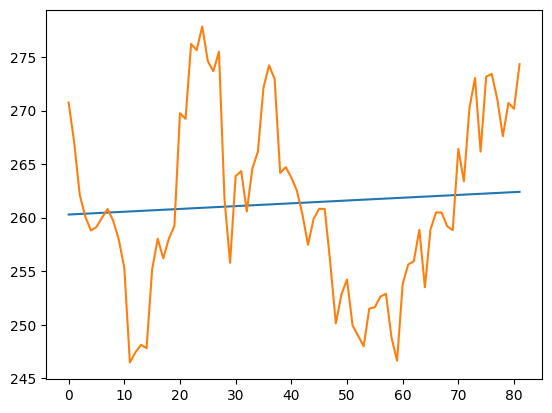

In [25]:
plt.plot(np.arange(len(prices)), trendline)
plt.plot(np.arange(len(prices)), prices)
plt.show()

In [26]:
# Using moving average to remove trend
window = 12
prices_na = prices.rolling(window=window).mean()
prices_detrended = prices - prices_na
prices_detrended = prices_detrended.dropna()

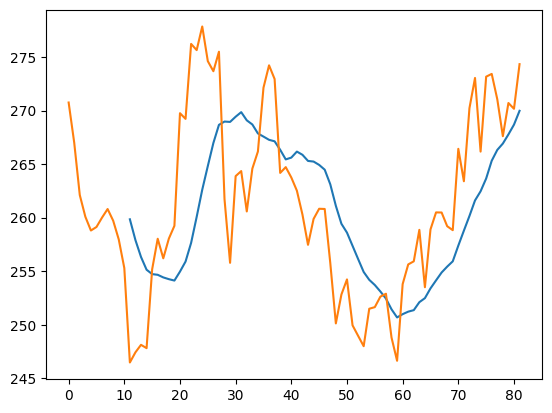

In [27]:
plt.plot(np.arange(len(prices)), prices_na)
plt.plot(np.arange(len(prices)), prices)
plt.show()

In [28]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Seasonal decomposition using moving averages
decomposition = seasonal_decompose(prices_1d, model='additive', period=30)
prices_adjusted = prices_1d / decomposition.seasonal
prices_adjusted = prices_adjusted.dropna()

In [29]:
adf_test(prices_adjusted)

ADF Statistics:  -2.7611718164371117
p-value:  0.06403771008970563
Critical Value (1%): -3.527
Critical Value (5%): -2.904
Critical Value (10%): -2.589


## White Noise and Random Walk

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.diagnostic import acorr_ljungbox

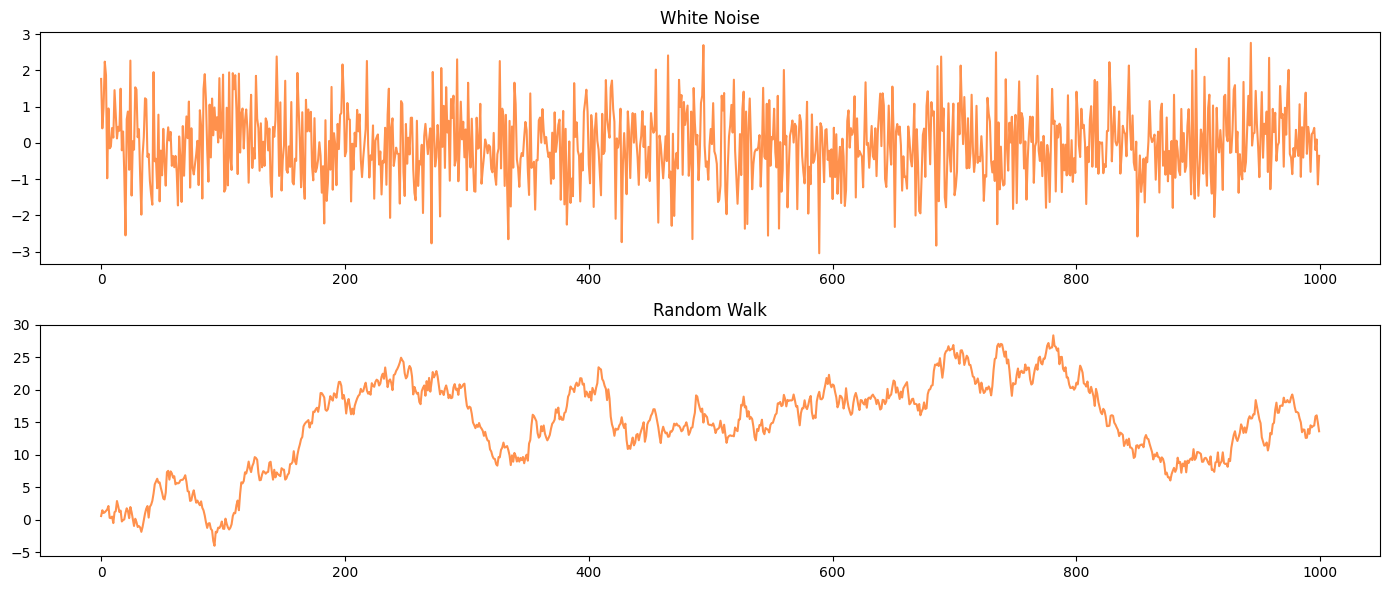


 Ljung-Box Test for White Noise:
      lb_stat  lb_pvalue
10  14.025574   0.171828

 Ljung-Box Test for Random Walk:
        lb_stat  lb_pvalue
10  8828.660312        0.0


In [31]:
np.random.seed(0)
n = 1000

# White Noise
white_noise = np.random.normal(0, 1, n)

# Random Walk
random_shocks = np.random.normal(0, 1, n)
random_walk = np.cumsum(random_shocks)

# Plotting the series 
plt.figure(figsize=(14, 6))

plt.subplot(2, 1, 1)
plt.plot(white_noise, color= '#FF914D')
plt.title(f'White Noise')

plt.subplot(2, 1, 2)
plt.plot(random_walk, color= '#FF914D')
plt.title(f'Random Walk')

plt.tight_layout()
plt.show()

print("\n Ljung-Box Test for White Noise:")
lb_test_white_noise = acorr_ljungbox(white_noise, lags=[10], return_df=True)
print(lb_test_white_noise)

print("\n Ljung-Box Test for Random Walk:")
lb_test_random_walk = acorr_ljungbox(random_walk, lags=[10], return_df=True)
print(lb_test_random_walk)

## Time Series Fmorecasting Models

### AR Model

In [32]:
# making data stationary before model fitting
stock_data = yf.download('AAPL', start='2024-01-01')

apple_price_stationary = stock_data['Close'].diff().dropna()

# Split the data into training and testing datasets
train_data, test_data = apple_price_stationary[:-30], apple_price_stationary[-30:]

[*********************100%***********************]  1 of 1 completed


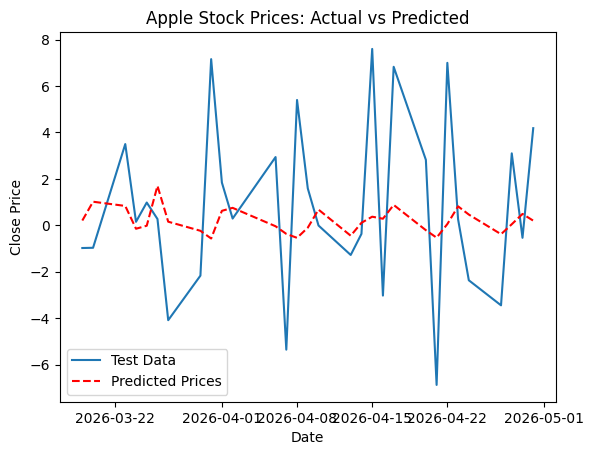

RMSE:  3.71


In [33]:
from statsmodels.tsa.ar_model import AutoReg
from sklearn.metrics import mean_squared_error
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Fit the Autoregressive model (AR) to the training data
model = AutoReg(train_data, lags=30)
model_fit = model.fit()

# Make prediction on the test data
predictions = model_fit.predict(
    start=len(train_data),
    end=len(train_data) + len(test_data)-1,
    dynamic=False
)

 # Plot the actual vs predicted values
plt.Figure(figsize=(10, 5))
plt.plot(test_data.index, test_data, label='Test Data')
plt.plot(test_data.index, predictions, color='red', linestyle='--', label='Predicted Prices')
plt.title('Apple Stock Prices: Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()

# Evaluating the model using RSME score 
rmse = round(np.sqrt(mean_squared_error(test_data, predictions)), 2)
print('RMSE: ', rmse)

### MA Model

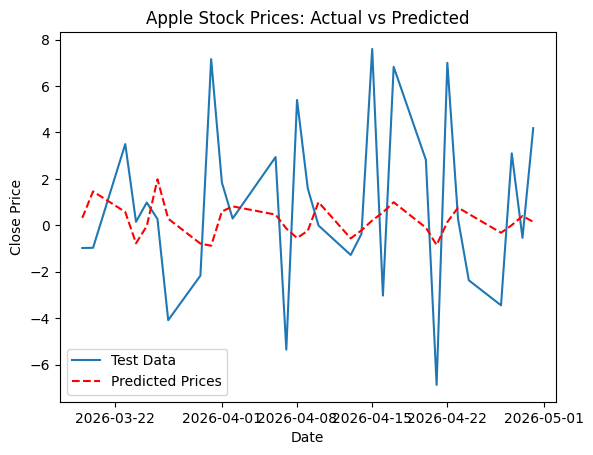

RMSE:  3.75


In [34]:
from statsmodels.tsa.arima.model import ARIMA

# Fit the Moving Average (MA) model to the training data
model = ARIMA(train_data, order=(0, 0, 30))
model_fit = model.fit()

# Make predictions on the test data
predictions = model_fit.predict(
    start=len(train_data),
    end=len(train_data) + len(test_data) -1,
    dynamic=False
)

# Plot the actual vs predicted values
plt.Figure(figsize=(10, 5))
plt.plot(test_data.index, test_data, label='Test Data')
plt.plot(test_data.index, predictions, color='red', linestyle='--', label='Predicted Prices')
plt.title('Apple Stock Prices: Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()

# Evaluating the model using RSME score 
rmse = round(np.sqrt(mean_squared_error(test_data, predictions)), 2)
print('RMSE: ', rmse)

### ARMA Model

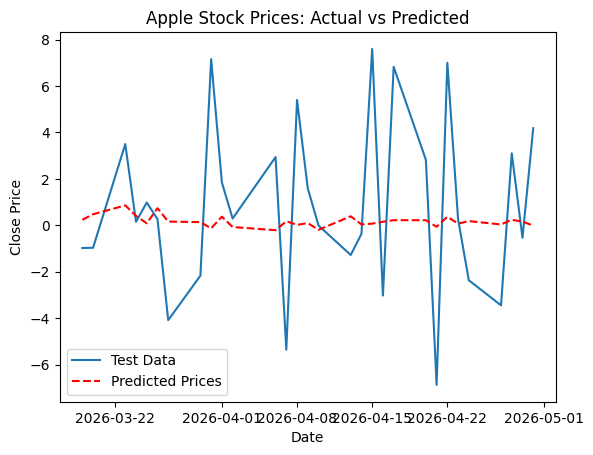

RMSE:  3.73


In [35]:
model = ARIMA(train_data, order=(7, 0, 7))
model_fit = model.fit()

# Make predictions on the test data
predictions = model_fit.predict(
    start=len(train_data),
    end=len(train_data) + len(test_data) -1,
    dynamic=False
)

# Plot the actual vs predicted values
plt.Figure(figsize=(10, 5))
plt.plot(test_data.index, test_data, label='Test Data')
plt.plot(test_data.index, predictions, color='red', linestyle='--', label='Predicted Prices')
plt.title('Apple Stock Prices: Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()

# Evaluating the model using RSME score 
rmse = round(np.sqrt(mean_squared_error(test_data, predictions)), 2)
print('RMSE: ', rmse)

### ARIMA Model

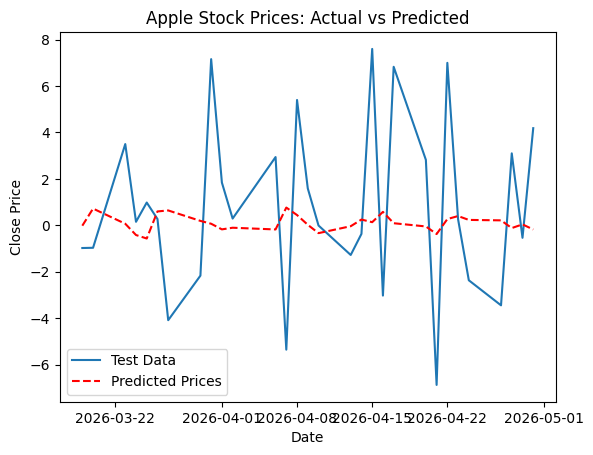

RMSE:  3.82


In [36]:
model = ARIMA(train_data, order=(7, 1, 7))
model_fit = model.fit()

# Make predictions on the test data
predictions = model_fit.predict(
    start=len(train_data),
    end=len(train_data) + len(test_data) -1,
    dynamic=False
)

# Plot the actual vs predicted values
plt.Figure(figsize=(10, 5))
plt.plot(test_data.index, test_data, label='Test Data')
plt.plot(test_data.index, predictions, color='red', linestyle='--', label='Predicted Prices')
plt.title('Apple Stock Prices: Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()

# Evaluating the model using RSME score 
rmse = round(np.sqrt(mean_squared_error(test_data, predictions)), 2)
print('RMSE: ', rmse)

### SARIMA Model

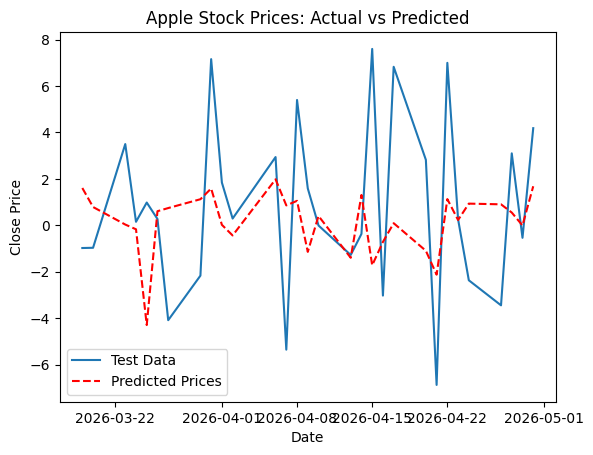

RMSE:  3.83


In [37]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

p, d, q = 7, 1, 7
P, D, Q, s = 1, 1, 1, 45

# Fit the SARIMA model
model = SARIMAX(train_data, order=(p, d, q), seasonal_order=(P, D, Q, s))
model_fit = model.fit()

# Make prediction on the test data
predictions = model_fit.predict(
    start=len(train_data),
    end=len(train_data) + len(test_data) -1,
    dynamic=False
)

# Plot the actual vs predicted values
plt.Figure(figsize=(10, 5))
plt.plot(test_data.index, test_data, label='Test Data')
plt.plot(test_data.index, predictions, color='red', linestyle='--', label='Predicted Prices')
plt.title('Apple Stock Prices: Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()

# Evaluating the model using RSME score 
rmse = round(np.sqrt(mean_squared_error(test_data, predictions)), 2)
print('RMSE: ', rmse)

### Vector Models

In [38]:
tsla_data = yf.download('TSLA', start='2024-01-01')

stock_data['TSLA_Close'] = tsla_data['Close']
stock_data['APPL_Close'] = stock_data['Close'].shift()
stock_data.dropna(inplace=True)

from statsmodels.tsa.stattools import grangercausalitytests

grangercausalitytests(stock_data[['APPL_Close', 'TSLA_Close']].dropna(), maxlag=[14])
print()

[*********************100%***********************]  1 of 1 completed


Granger Causality
number of lags (no zero) 14
ssr based F test:         F=7.4301  , p=0.0000  , df_denom=540, df_num=14
ssr based chi2 test:   chi2=109.6072, p=0.0000  , df=14
likelihood ratio test: chi2=100.2362, p=0.0000  , df=14
parameter F test:         F=7.4301  , p=0.0000  , df_denom=540, df_num=14



In [39]:
stock_data

Price,Close,High,Low,Open,Volume,TSLA_Close,APPL_Close
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,
Date,,,,,,,
2024-01-03,182.355606,183.968852,181.544030,182.325916,58414500,238.449997,183.731308
2024-01-04,180.039658,181.207518,179.020249,180.277180,71983600,237.929993,182.355606
2024-01-05,179.317169,180.880926,178.317559,180.118854,62379700,237.490005,180.039658
2024-01-08,183.652115,183.691712,179.633861,180.217791,59144500,240.449997,179.317169
2024-01-09,183.236435,183.246327,180.851210,182.028977,42841800,234.960007,183.652115
...,...,...,...,...,...,...,...
2026-04-24,271.059998,273.059998,269.649994,272.760010,38157100,376.299988,273.429993
2026-04-27,267.609985,268.359985,265.070007,266.089996,41466800,378.670013,271.059998


In [40]:
data = stock_data[['APPL_Close', 'TSLA_Close']].diff().dropna()
train_data, test_data = data[:-14], data[-14:]

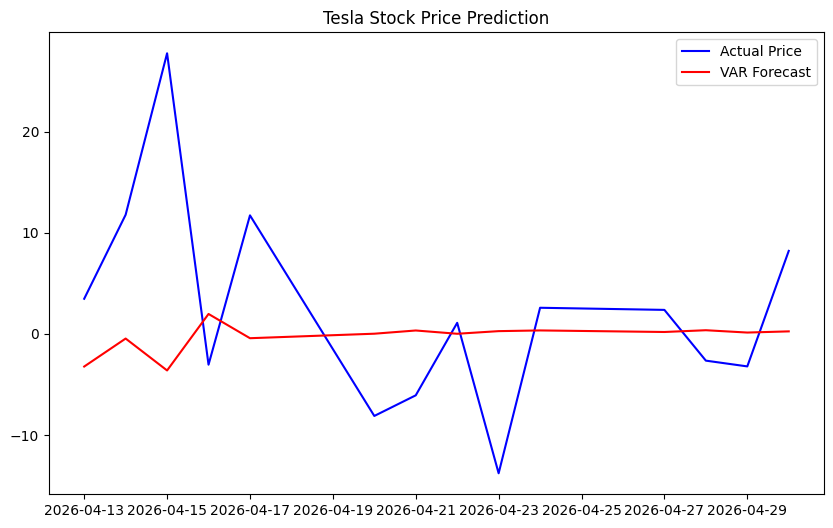

RMSE:  11.18


In [41]:
from statsmodels.tsa.api import VAR, VARMAX
import pandas as pd

# VAR
model = VAR(train_data)
result = model.fit(maxlags=7)
predictions = result.forecast(train_data.values[-result.k_ar:], steps=len(test_data))

predictions = pd.DataFrame(predictions, index=test_data.index, columns=test_data.columns)
plt.figure(figsize=(10,6))
plt.plot(test_data.index, test_data['TSLA_Close'], label='Actual Price', color='blue')
plt.plot(test_data.index, predictions['TSLA_Close'], label='VAR Forecast', color='red')
plt.legend()
plt.title('Tesla Stock Price Prediction')
plt.show()

# Evaluating the model using RSME score 
rmse = round(np.sqrt(mean_squared_error(test_data['TSLA_Close'], predictions['TSLA_Close'])), 2)
print('RMSE: ', rmse)

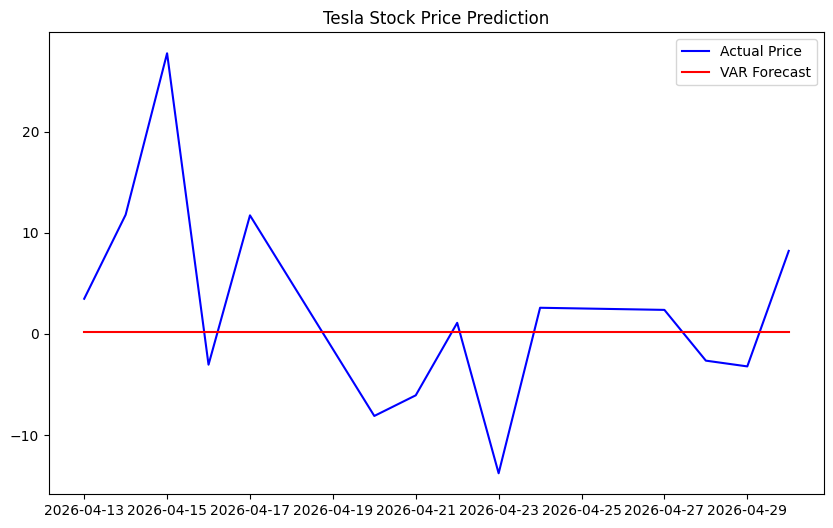

RMSE:  10.17


In [42]:
model = VARMAX(train_data, order=(0, 14))
result = model.fit()
predictions = result.predict(
    start=len(train_data),
    end=len(train_data) + len(test_data) - 1,
    dynamic=False
)

plt.figure(figsize=(10,6))
plt.plot(test_data.index, test_data['TSLA_Close'], label='Actual Price', color='blue')
plt.plot(test_data.index, predictions['TSLA_Close'], label='VAR Forecast', color='red')
plt.legend()
plt.title('Tesla Stock Price Prediction')
plt.show()

# Evaluating the model using RSME score 
rmse = round(np.sqrt(mean_squared_error(test_data['TSLA_Close'], predictions['TSLA_Close'])), 2)
print('RMSE: ', rmse)

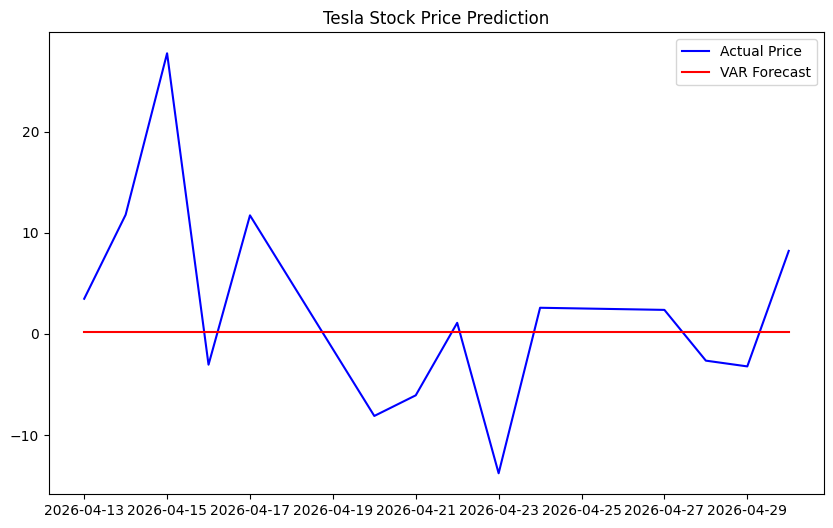

RMSE:  10.17


In [43]:
# VARIMA

model = VARMAX(train_data, order=(14, 14))
result = model.fit()
predictions = result.predict(
    start=len(train_data),
    end=len(train_data) + len(test_data) - 1,
    dynamic=False
)

plt.figure(figsize=(10,6))
plt.plot(test_data.index, test_data['TSLA_Close'], label='Actual Price', color='blue')
plt.plot(test_data.index, predictions['TSLA_Close'], label='VAR Forecast', color='red')
plt.legend()
plt.title('Tesla Stock Price Prediction')
plt.show()

# Evaluating the model using RSME score 
rmse = round(np.sqrt(mean_squared_error(test_data['TSLA_Close'], predictions['TSLA_Close'])), 2)
print('RMSE: ', rmse)

## Smoothing Methods

### Moving Average

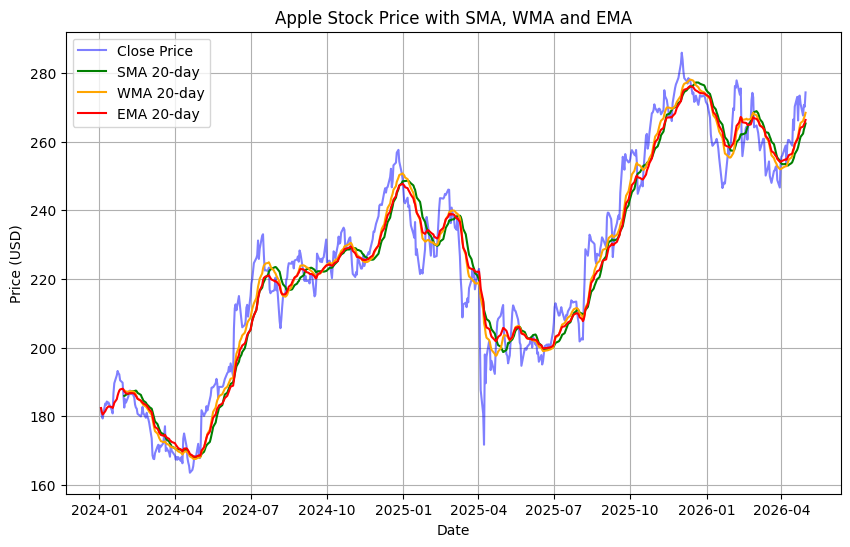

In [44]:
window_size = 20
stock_data['SMA'] = stock_data['Close'].rolling(window=window_size).mean()

# Calculate Weighted Moving Average
weights = np.arange(1, window_size + 1)
stock_data['WMA'] = stock_data['Close'].rolling(window_size).apply(lambda prices: np.dot(prices, weights) / weights.sum(), raw=True)

# Calculate Exponential Moving Average
stock_data['EMA'] = stock_data['Close'].ewm(span=window_size).mean()

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(stock_data['Close'], label='Close Price', color='blue', alpha=0.5)
plt.plot(stock_data['SMA'], label=f'SMA {window_size}-day', color='green')
plt.plot(stock_data['WMA'], label=f'WMA {window_size}-day', color='orange')
plt.plot(stock_data['EMA'], label=f'EMA {window_size}-day', color='red')

plt.title('Apple Stock Price with SMA, WMA and EMA')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid()
plt.show()

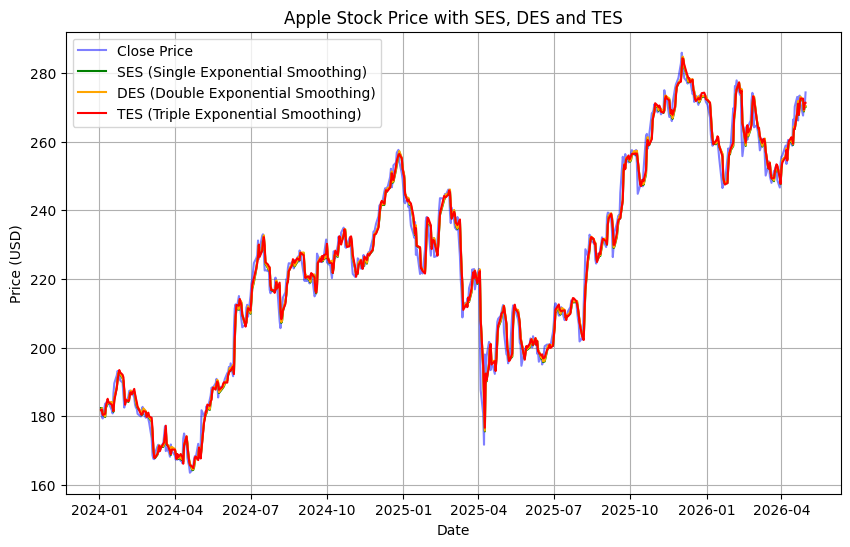

In [45]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing

close_prices = stock_data['Close']
ses_model = SimpleExpSmoothing(close_prices).fit(smoothing_level=0.7)
stock_data['SES'] = ses_model.fittedvalues

# Double Exponential Smoothing (DES) - Holt's Linear trend model
des_model = ExponentialSmoothing(close_prices, trend='add').fit(smoothing_level=0.7)
stock_data['DES'] = des_model.fittedvalues

# Triple Exponential Smoothing (TES) - Holt-Winters's method
tes_model = ExponentialSmoothing(close_prices, trend='add', seasonal='add', seasonal_periods=12).fit(smoothing_level=0.7)
stock_data['TES'] = tes_model.fittedvalues

plt.figure(figsize=(10, 6))
plt.plot(stock_data['Close'], label='Close Price', color='blue', alpha=0.5)
plt.plot(stock_data['SES'], label='SES (Single Exponential Smoothing)', color='green')
plt.plot(stock_data['DES'], label='DES (Double Exponential Smoothing)', color='orange')
plt.plot(stock_data['TES'], label='TES (Triple Exponential Smoothing)', color='red')

plt.title('Apple Stock Price with SES, DES and TES')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid()
plt.show()
